# Descriptive statistics on EA HICP

In [24]:
# Librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fismi import sdxData as sdx

np.set_printoptions(suppress=True, precision=4)
plt.rcParams["figure.figsize"] = (9, 5)

In [27]:
# Unchained other items 
niv = "1"
dfICP = pd.read_parquet(f"input/EAunchainedItemsLvl{niv}.parquet")
dfW = pd.read_parquet(f"input/EAnormedWeightsLvl{niv}.parquet") 

/var/folders/zg/2lsdtr0j4fq844zjvs8ybwfc0000gn/T/ipykernel_15448/1347820160.py:26: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


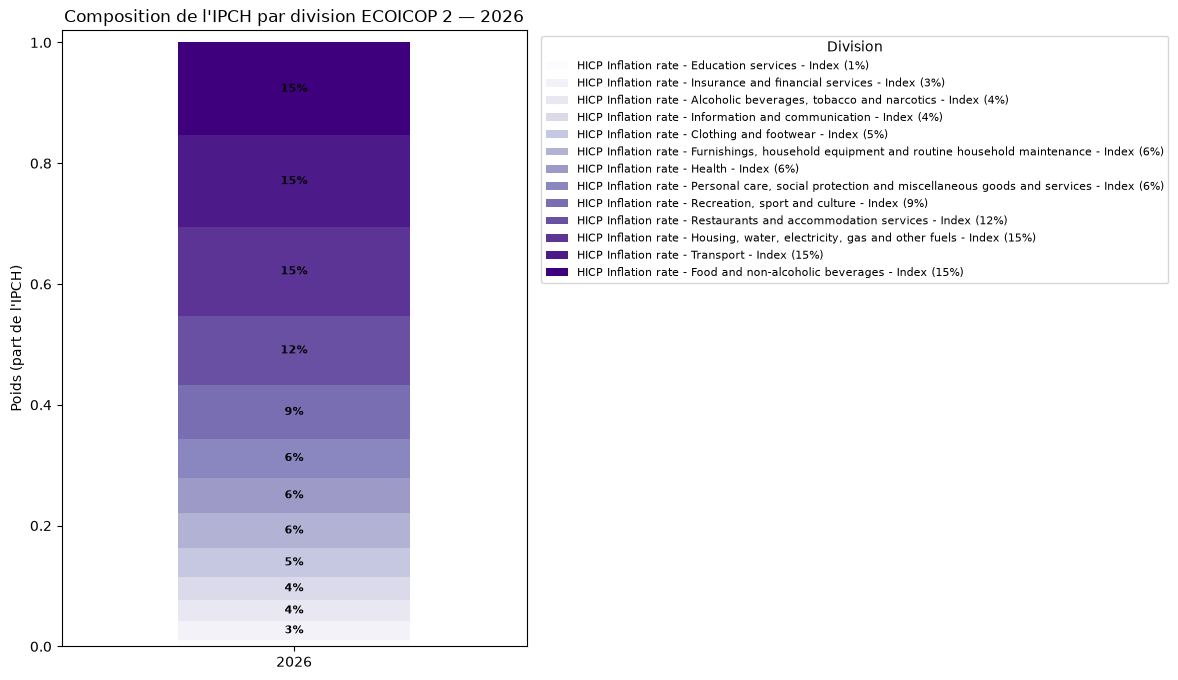

In [40]:
# plot bars in stack manner
yyyy = 2026

dfW_annuel = dfW.groupby(dfW.index.year).first()
dfW_annuel.index.name = "Year"

fig, ax = plt.subplots(figsize=(6, 8))
rowYear = dfW_annuel.loc[yyyy].sort_values(ascending=True)
rowYear.to_frame().T.plot(kind="bar", stacked=True, ax=ax, width=0.5, colormap="Purples")

ax.set_ylabel("Poids (part de l'IPCH)")
ax.set_xlabel("")
ax.set_title(f"Composition de l'IPCH par division ECOICOP 2 — {yyyy}")
ax.set_xticklabels([str(yyyy)], rotation=0)
ax.set_ylim(0, 1.02)

SEUIL_LABEL = 0.03
for container, col in zip(ax.containers, rowYear.index):
    val = rowYear[col]                       # scalaire direct, plus de .iloc[0]
    label = f"{val*100:.0f}%" if val >= SEUIL_LABEL else ""
    ax.bar_label(container, labels=[label], label_type="center", fontsize=8, color="black", fontweight="bold")

legend_labels = [f"{col} ({rowYear[col]*100:.0f}%)" for col in rowYear.index]   # .index, pas .columns
ax.legend(legend_labels, title="Division", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()